# Cassini CDA Dust Analyzer: Ablation Study
This notebook splits labeled data into a fixed test dataset (10 spectra per class, stratified) and a flexible pool for few-shot training. It evaluates Gemini's classification accuracy using a varying number of few-shot examples (1, 2, 4, 8, 16, 32) generated by the built-in VLM explainer. Results and confusion matrices are saved for further inspection.

In [1]:
import importlib
import scripts.run_ablation_study
importlib.reload(scripts.run_ablation_study)
from scripts.run_ablation_study import preprocess_huggingface_data

In [2]:
import os
import sys
import json
import base64
import asyncio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from dotenv import load_dotenv

# Ensure we can import from the workspace
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from google import genai
from google.genai import types

from cda_dust_agent.config import Config
from cda_dust_agent.prompts import SYSTEM_INSTRUCTION_TEXT, CLASSIFICATION_USER_PROMPT, ANNOTATION_USER_PROMPT
from cda_dust_agent.tools.utils import generate_spectrum_image_bytes
from scripts.run_ablation_study import preprocess_huggingface_data, generate_explanation, classify_spectrum

# Load environment variable for Vertex AI / Gemini access
load_dotenv()
config = Config()
client = genai.Client()
model_id = config.agent_settings.model

print(f"Using Model: {model_id}")

Using Model: gemini-3.1-pro-preview


In [3]:
# 1. Fetch and Preprocess Data
print("Loading data...")
full_df = preprocess_huggingface_data("H")
print(f"Total available rows: {len(full_df)}")

# Display the class distribution to check preprocessing
print("Class counts:")
print(full_df['class'].value_counts())

Loading data...
Loading processed H dataset(s) generated by DataFetchAndParseAgent...
Total available rows: 6986
Class counts:
class
Noise    4442
1        1183
2         829
3         246
4         210
5          42
5-Na       34
Name: count, dtype: int64


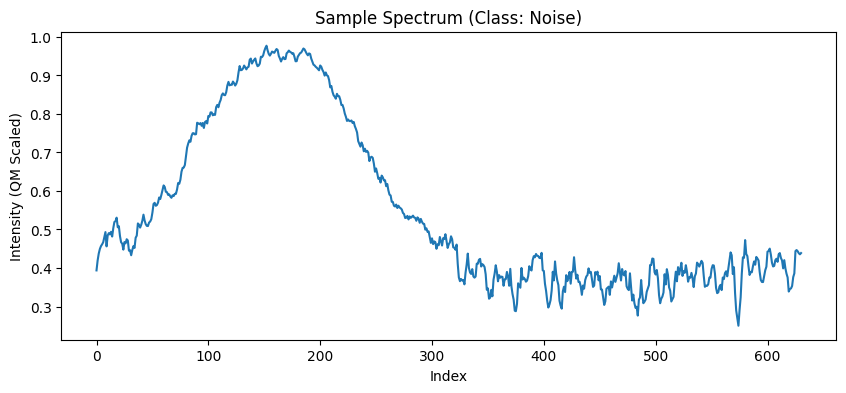


Final Test Set Size: 70 (10 per viable class)
Total remaining pool for training: 6916


In [ ]:
# Optional: Plot the first spectrum to verify format
first_spec = full_df.iloc[0]['spectrum']
plt.figure(figsize=(10,4))
plt.plot(first_spec)
plt.title(f"Sample Spectrum (Class: {full_df.iloc[0]['class']})")
plt.xlabel("Index")
plt.ylabel("Intensity (QM Scaled)")
plt.show()

# 2. Split Data: Fixed Test Set and Remaining Pool
TEST_SIZE_PER_CLASS = 10
MAX_FEW_SHOT = 32

test_dfs = []
pool_dfs = []

# Only keep classes that have at least (TEST_SIZE_PER_CLASS) examples
for cls, group in full_df.groupby('class'):
    if len(group) >= TEST_SIZE_PER_CLASS + 1:
        # Shuffle
        group = group.sample(frac=1, random_state=42).reset_index(drop=True)
        test_dfs.append(group.head(TEST_SIZE_PER_CLASS))
        pool_dfs.append(group.tail(len(group) - TEST_SIZE_PER_CLASS))
    else:
        print(f"Skipping class '{cls}' - not enough samples ({len(group)})")

test_df = pd.concat(test_dfs, ignore_index=True)
pool_df = pd.concat(pool_dfs, ignore_index=True)

print(f"\nFinal Test Set Size: {len(test_df)} ({TEST_SIZE_PER_CLASS} per viable class)")
print(f"Total remaining pool for training: {len(pool_df)}")

In [ ]:
display(pool_df)

NameError: name 'train_pool_df' is not defined

In [ ]:
# 3. Ablation Study Execution
import logging

# Suppress verbose Google GenAI AFC logging
logging.getLogger("google_genai").setLevel(logging.WARNING)

k_values = [1, 2, 4, 8, 12, 16, 24, 32]
results_dir = os.path.join(os.getcwd(), 'ablation_results')
os.makedirs(results_dir, exist_ok=True)

# User-defined upper limits for training to preserve testing data
max_train_map = {
    '5': 16,
    '5-Na': 16
}

async def run_experiment():
    api_semaphore = asyncio.Semaphore(5)
    
    for k in k_values:
        print(f"\n{'='*40}\nRunning inference for k={k} shot learning\n{'='*40}")
        
        # a. Sample k per class from Training Pool (up to their explicit limits)
        explanation_tasks = []
        
        for cls in pool_df['class'].unique():
            cls_pool = pool_df[pool_df['class'] == cls]
            
            # Determine how many we can actually sample for this class
            k_actual = min(k, max_train_map.get(cls, 32), len(cls_pool))
            
            class_pool = cls_pool.sample(n=k_actual, random_state=123)
            for _, row in class_pool.iterrows():
                task = generate_explanation(client, model_id, row['spectrum'], row['class'], row['sclk'], api_semaphore)
                explanation_tasks.append(task)
                
        print(f"[{datetime.now().strftime('%H:%M:%S')}] Generating {len(explanation_tasks)} explanations via VLM...")
        explanations = []
        for i, completed_task in enumerate(asyncio.as_completed(explanation_tasks), 1):
            res = await completed_task
            explanations.append(res)
            if i % 10 == 0 or i == len(explanation_tasks):
                print(f"    -> Generated {i}/{len(explanation_tasks)} explanations...")
                
        k_shot_examples = [res for res in explanations if res is not None]
        
        # b. Test on fixed test_df
        print(f"[{datetime.now().strftime('%H:%M:%S')}] Classifying {len(test_df)} test spectra...")
        classification_tasks = []
        for _, row in test_df.iterrows():
            task = classify_spectrum(client, model_id, row, k_shot_examples, api_semaphore)
            classification_tasks.append(task)
            
        predictions = []
        for i, completed_task in enumerate(asyncio.as_completed(classification_tasks), 1):
            res = await completed_task
            predictions.append(res)
            if i % 10 == 0 or i == len(classification_tasks):
                print(f"    -> Classified {i}/{len(classification_tasks)} spectra...")
        
        # c. Save results to DataFrame and Parquet
        results_df = pd.DataFrame(predictions)
        
        parquet_path = os.path.join(results_dir, f"results_k{k}.parquet")
        results_df.to_parquet(parquet_path)
        print(f"[{datetime.now().strftime('%H:%M:%S')}] Saved results to {parquet_path}")
        
        # Compute subset accuracy excluding errors
        valid_preds = results_df[results_df['predicted_label'] != 'error']
        acc = accuracy_score(valid_preds['true_label'], valid_preds['predicted_label'])
        print(f"Accuracy for k={k}: {acc:.2%}")
        
        # d. Confusion Matrix
        labels = sorted(test_df['class'].unique())
        cm = confusion_matrix(results_df['true_label'], results_df['predicted_label'], labels=labels)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.title(f"Confusion Matrix (k={k} shots) - Acc: {acc:.2%}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        
        cm_path = os.path.join(results_dir, f"confusion_matrix_k{k}.png")
        plt.savefig(cm_path)
        plt.close()
        print(f"Saved Confusion Matrix to {cm_path}")

# To run the async function in Jupyter
from datetime import datetime
await run_experiment()


Running inference for k=1 shot learning
[07:13:33] Generating 12 explanations via VLM...
    -> Generated 10/12 explanations...
    -> Generated 12/12 explanations...
[07:14:05] Classifying 211 test spectra...
Classification failed for (sclk: 1498471387): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}. Retrying 1/3...
    -> Classified 10/211 spectra...
    -> Classified 20/211 spectra...
Classification failed for (sclk: 1514183850): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}. Retrying 1/3...
Classification failed for (sclk: 1503256992): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}. Retrying 1/3...
Classification failed for (sclk: 1503256992): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'mess

CancelledError: 

Classification failed for (sclk: 1509344418): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}. Retrying 1/3...
